# Customer Churn Prediction for a Telecommunications Company
# Problem Statement
Customer churn is a major challenge for telecommunications companies, as losing customers directly impacts revenue and profitability. Identifying customers who are likely to discontinue services allows businesses to take proactive measures to improve retention.
# Project Goal
The goal of this project is to develop a machine learning model that predicts whether a customer is likely to churn based on demographic information, account details, and service usage patterns.
# Success Metrics
The performance of the models will be evaluated using:
    Accuracy
    Precision
    Recall
    F1 Score
    ROC-AUC Score
# Business Impact
By identifying high-risk customers, the company can implement targeted retention strategies, reduce customer attrition, and improve overall profitability.

# Data Collection and Exploration
The dataset used in this project is the Telco Customer Churn Dataset. It contains customer demographic information, account details, subscribed services, and whether the customer churned.
The objective of this stage is to understand the structure of the dataset, identify potential data quality issues, and prepare for exploratory data analysis.

In [1]:
#import libraries
#Data manipulation
import pandas as pd
import numpy as np
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns
#Display settings
pd.set_option('display.max_columns', None)
#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Load dataset
df = pd.read_excel("Telco-Customer-Churn.csv.xlsx")
#Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check dataset dimensions
print("Rows and Columns:", df.shape)

Rows and Columns: (7043, 21)


# Observation
The dataset contains customer records and multiple features describing demographics, services, billing information, and churn status.

In [5]:
#Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Observation
The dataset contains both numerical and categorical variables.
The TotalCharges column may require conversion to a numeric data type because it is often loaded as an object due to missing or blank values.

In [6]:
#Numerical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
#Missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
#Check duplicate 
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
#Unique values per column
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [10]:
#Churn distribution
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# Initial Findings
Key observations from the dataset:
1. The dataset contains customer demographic and service-related information.
2. Both numerical and categorical features are present.
3. Churn is the target variable.
4. Data quality issues such as blank values in TotalCharges may require cleaning.
5. The dataset appears suitable for a supervised classification.

# Exploratory Data Analysis (EDA)
The purpose of exploratory data analysis is to understand customer behavior patterns, identify relationships between variables, and discover factors that may influence customer churn.
This section uses visualizations to uncover trends and generate business insights.

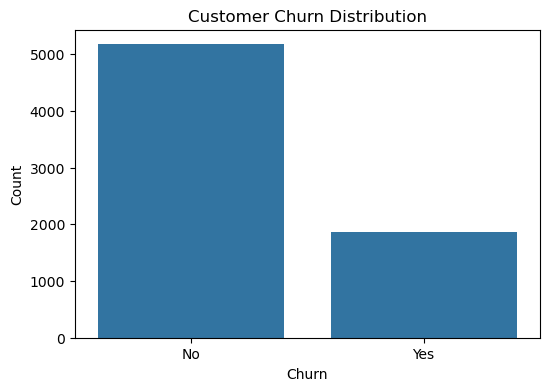

In [11]:
#churn distribution bar graph
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

# Observation
Most customers did not churn, indicating that the dataset is moderately imbalanced.
This suggests that model evaluation should not rely solely on accuracy, metrics such as precision, recall, F1-score, and ROC-AUC will also be important.

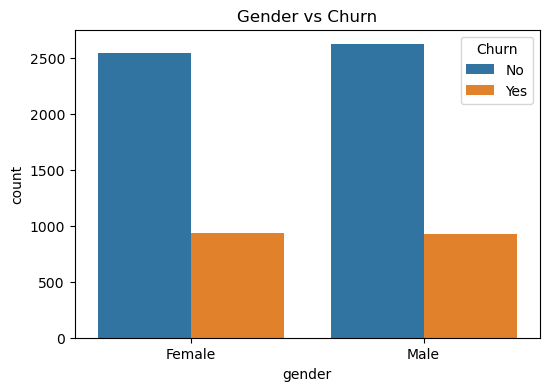

In [12]:
#Gender vs churn bar graph
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Churn', data=df)
plt.title('Gender vs Churn')
plt.show()

# Observation
Customer churn appears relatively similar across genders, suggesting gender alone may not be a strong predictor of churn.

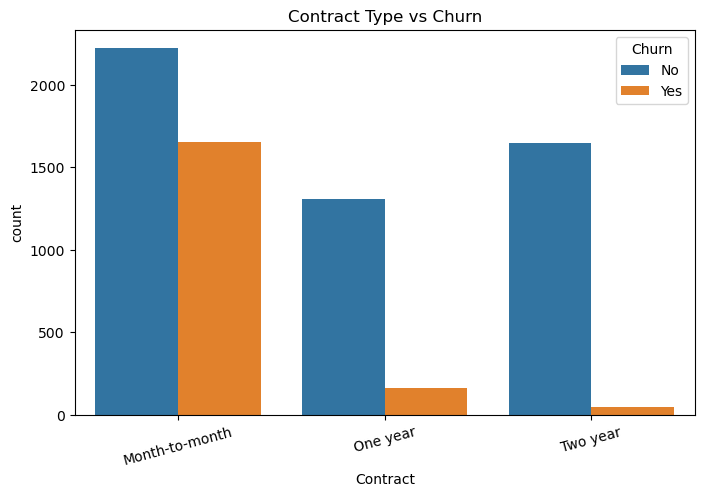

In [13]:
#Contract type vs churn
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.xticks(rotation=15)
plt.show()

# Observation
Customers on month-to-month contracts appear more likely to churn than customers on one-year or two-year contracts.
Long-term contracts may increase customer retention.

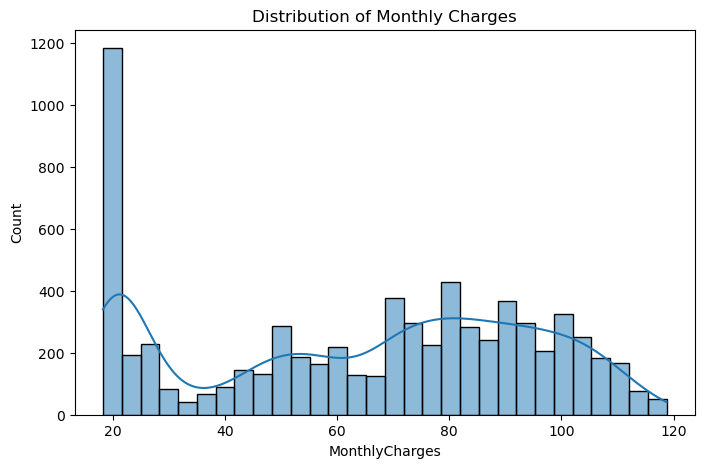

In [14]:
#Monthly charges distribution
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title('Distribution of Monthly Charges')
plt.show()

# Observation
Monthly charges vary considerably across customers, indicating diverse service packages and pricing plans.

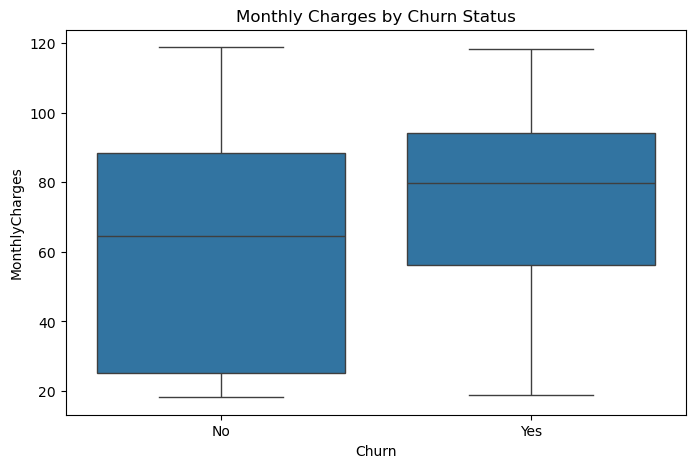

In [15]:
#Monthly charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title('Monthly Charges by Churn Status')
plt.show()

# Observation
Customers who churn tend to have higher monthly charges than those who remain with the company.
Pricing may be an important factor influencing churn.

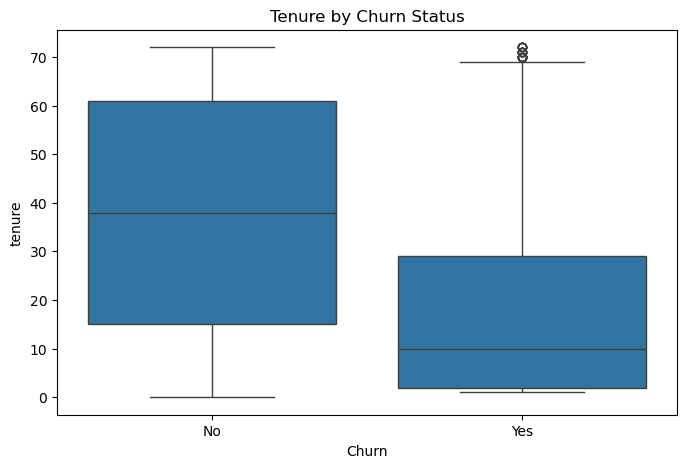

In [16]:
#Churn vs Tenure
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='tenure',data=df)
plt.title('Tenure by Churn Status')
plt.show()

# Observation
Customers who churn generally have lower tenure compared to retained customers.
New customers may be at greater risk of leaving.

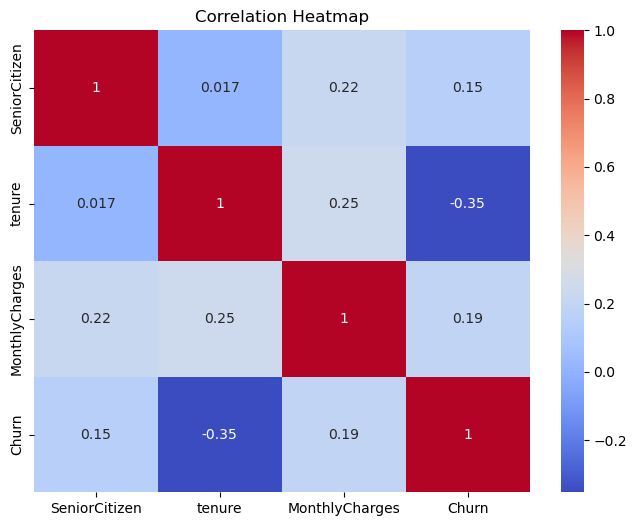

In [17]:
#Correlation heatmap
numeric_df = df.copy()
numeric_df['Churn'] = numeric_df['Churn'].map({'No':0, 'Yes':1})
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.select_dtypes(include=['int64','float64']).corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Observation
Tenure and Monthly Charges show meaningful relationships with churn and may become important predictive features during modeling.

# EDA Summary
Key findings from exploratory analysis:
1. Customers on month-to-month contracts are more likely to churn.
2. Customers with shorter tenure have higher churn rates.
3. Higher monthly charges appear associated with churn.
4. Gender does not appear to strongly influence churn.
5. Contract type and tenure are likely important predictors.
These findings provide direction for feature engineering and model development.

# Data Cleaning and Preprocessing
Before building machine learning models, the dataset must be cleaned and transformed into a suitable format.
The following steps are performed:
- Convert data types
- Handle missing values
- Remove unnecessary columns
- Encode categorical variables
- Scale numerical features
- Prepare data for modeling

# Observation
The TotalCharges column contains blank spaces that were not detected as missing values because they are stored as text.

In [30]:
#Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [32]:
# Remove rows with missing TotalCharges
df.dropna(inplace=True)

print(df.shape)

(7032, 20)


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [35]:
df["Churn"].head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

In [36]:
#encode target variable
df["Churn"]=df["Churn"].map({"No":0,"Yes":1})

In [37]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [38]:
#create x and y
X = df.drop('Churn', axis=1)
y = df['Churn']

In [39]:
categorical_cols = X.select_dtypes(include='object').columns
categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [40]:
#one hot encoding
X = pd.get_dummies(X,drop_first=True)

In [41]:
#Train Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [42]:
print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


In [43]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Data Cleaning Summary
The following preprocessing steps were completed:
- Converted TotalCharges to numeric format.
- Removed rows with missing values.
- Encoded the target variable.
- Applied one-hot encoding to categorical variables.
- Split the dataset into training and testing sets.
- Standardized numerical features.
The dataset is now ready for machine learning model development.

# Feature Engineering and Feature Selection
Feature engineering involves creating new variables from existing data to better represent customer behavior.Feature selection helps identify the most important variables for predicting customer churn, reducing noise and improving model performance.

In [44]:
#Create customer tenure groups
df['Tenure_Group'] = pd.cut(df['tenure'],bins=[0, 12, 24, 48, 72],labels=['New', 'Developing', 'Established', 'Loyal'])
df[['tenure', 'Tenure_Group']].head()

,tenure,Tenure_Group
0,1,New
1,34,Established
2,2,New
3,45,Established
4,2,New


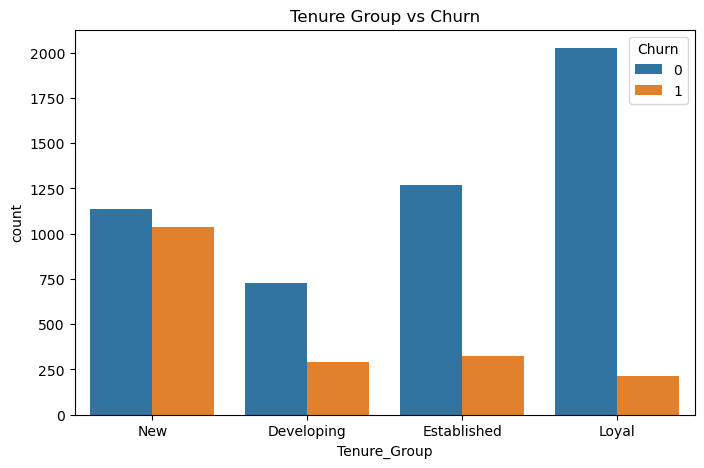

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tenure_Group',hue='Churn',data=df)
plt.title('Tenure Group vs Churn')
plt.show()

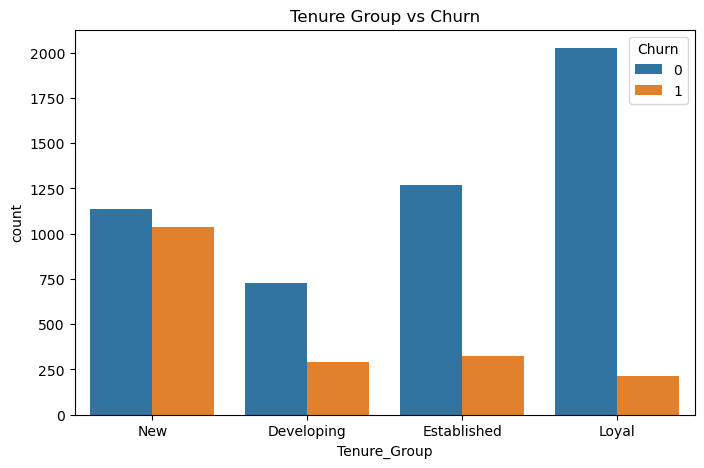

In [46]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tenure_Group',hue='Churn',data=df)
plt.title('Tenure Group vs Churn')
plt.show()

# Observation
Customers in the "New" category appear more likely to churn than long-term customers. This suggests that customer retention efforts should focus on the early stages of the customer lifecycle.

In [47]:
#Create avarage revenue per month
df['Revenue_Per_Month'] = np.where(df['tenure'] == 0,0,df['TotalCharges'] / df['tenure'])
df[['Revenue_Per_Month']].head()

,Revenue_Per_Month
0,29.850000
1,55.573529
2,54.075000
3,40.905556
4,75.825000


# Observation
Revenue per month provides an estimate of customer spending behavior and may reveal differences between retained and churned customers.

In [48]:
#rebuilding features (x and y)
X = df.drop('Churn', axis=1)
y = df['Churn']

In [49]:
#encoding new features
X = pd.get_dummies(X,drop_first=True)
print(X.shape)

(7032, 34)


In [50]:
#correlation with churn
corr_with_target = X.corrwith(y)
corr_with_target.sort_values(ascending=False).head(15)

InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
Revenue_Per_Month                 0.192033
PaperlessBilling_Yes              0.191454
SeniorCitizen                     0.150541
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
Tenure_Group_Developing           0.019929
PhoneService_Yes                  0.011691
gender_Male                      -0.008545
MultipleLines_No phone service   -0.011691
DeviceProtection_Yes             -0.066193
Tenure_Group_Established         -0.075859
dtype: float64

# Observation
Features with stronger positive correlations may increase churn risk, while features with negative correlations may be associated with customer retention.

In [51]:
#Random forest
from sklearn.ensemble import RandomForestClassifier

In [52]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [53]:
feature_importance = pd.Series(rf.feature_importances_,index=X.columns)
top_features = feature_importance.sort_values(ascending=False).head(15)
top_features

TotalCharges                      0.153280
tenure                            0.144057
Revenue_Per_Month                 0.135537
MonthlyCharges                    0.128557
PaymentMethod_Electronic check    0.034106
InternetService_Fiber optic       0.033720
Contract_Two year                 0.028720
gender_Male                       0.024180
PaperlessBilling_Yes              0.022076
OnlineSecurity_Yes                0.020783
TechSupport_Yes                   0.020332
Partner_Yes                       0.019621
OnlineBackup_Yes                  0.018932
Contract_One year                 0.018876
SeniorCitizen                     0.018090
dtype: float64

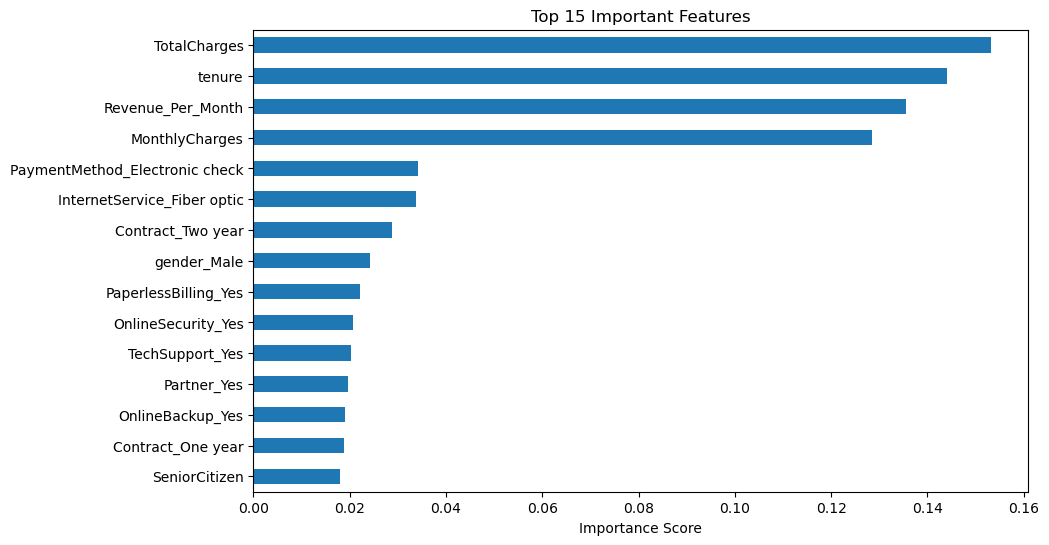

In [54]:
#visualize feature importance
plt.figure(figsize=(10,6))
top_features.sort_values().plot(kind='barh')
plt.title('Top 15 Important Features')
plt.xlabel('Importance Score')
plt.show()

# Observation
The most important features include customer tenure, total charges, monthly charges, contract type, and service-related variables.These factors play a major role in determining whether a customer is likely to churn.

## Feature Importance Insights
The most influential features for predicting customer churn are:
1. TotalCharges
2. Tenure
3. Revenue_Per_Month
4. MonthlyCharges
Key observations:
- Customers with shorter tenure are more likely to leave.
- Monthly and total spending play a significant role in churn behavior.
- Customers paying through electronic checks appear more likely to churn.
- Customers using fiber optic internet show higher churn risk.
- Long-term contracts contribute to customer retention.
These findings suggest that pricing strategies, contract structures, and early customer engagement are important areas for reducing churn.

# Model Selection and Training
Three machine learning models are trained and compared:
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

The objective is to determine which model best predicts customer churn while maintaining good generalization performance.

In [55]:
# Rebuild features
X = df.drop('Churn', axis=1)
y = df['Churn']
# Encode categoricals
X = pd.get_dummies(X, drop_first=True)

In [57]:
#split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
#Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
#import models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [59]:
#logistic regression
log_model = LogisticRegression(max_iter=1000,random_state=42)
log_model.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [60]:
#Decision trees
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [61]:
#Random forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [62]:
#predictions
log_pred = log_model.predict(X_test_scaled)

dt_pred = dt_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

In [63]:
#Accuracy
from sklearn.metrics import accuracy_score
print("Logistic Regression:",accuracy_score(y_test, log_pred))
print("Decision Tree:",accuracy_score(y_test, dt_pred))
print("Random Forest:",accuracy_score(y_test, rf_pred))

Logistic Regression: 0.7953091684434968
Decision Tree: 0.7171286425017769
Random Forest: 0.7896233120113717


In [64]:
#compare
results = pd.DataFrame({"Model": ["Logistic Regression","Decision Tree","Random Forest"],"Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)]})
results

,Model,Accuracy
0,Logistic Regression,0.795309
1,Decision Tree,0.717129
2,Random Forest,0.789623


# Model Training Results

Three machine learning models were trained and evaluated.

Results show that:

- Logistic Regression achieved the highest accuracy (79.53%).
- Random Forest performed similarly (78.96%).
- Decision Tree produced the lowest accuracy (71.71%).

The strong performance of Logistic Regression suggests that the relationship between the predictors and customer churn is relatively well captured by a linear decision boundary.Further evaluation using precision, recall, F1-score, ROC-AUC, and confusion matrices will help determine the most suitable model.

# Model Evaluation and Interpretation
Model performance is evaluated using multiple metrics to provide a more comprehensive assessment than accuracy alone.

The following metrics are used:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Additionally, confusion matrices and ROC curves are used to visualize model performance.

In [66]:
#import metrics
from sklearn.metrics import(classification_report,confusion_matrix,roc_auc_score,roc_curve,precision_score,recall_score,
    f1_score)

In [67]:
#create evaluation tables
evaluation_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)]})

evaluation_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795309,0.63871,0.529412,0.578947
1,Decision Tree,0.717129,0.46875,0.481283,0.474934
2,Random Forest,0.789623,0.63000,0.505348,0.560831


In [68]:
#Calculate ROC-AUC
log_auc = roc_auc_score(y_test,log_model.predict_proba(X_test_scaled)[:,1])
dt_auc = roc_auc_score(y_test,dt_model.predict_proba(X_test)[:,1])
rf_auc = roc_auc_score(y_test,rf_model.predict_proba(X_test)[:,1])
print("Logistic Regression AUC:", log_auc)
print("Decision Tree AUC:", dt_auc)
print("Random Forest AUC:", rf_auc)

Logistic Regression AUC: 0.8347150969866076
Decision Tree AUC: 0.6416491088206822
Random Forest AUC: 0.8182905301520415


In [69]:
evaluation_results["AUC"] = [log_auc,dt_auc,rf_auc]

evaluation_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.795309,0.63871,0.529412,0.578947,0.834715
1,Decision Tree,0.717129,0.46875,0.481283,0.474934,0.641649
2,Random Forest,0.789623,0.63000,0.505348,0.560831,0.818291


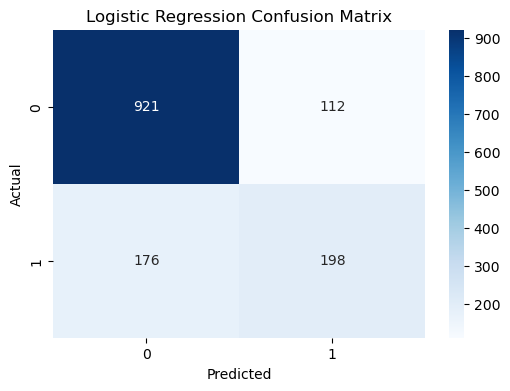

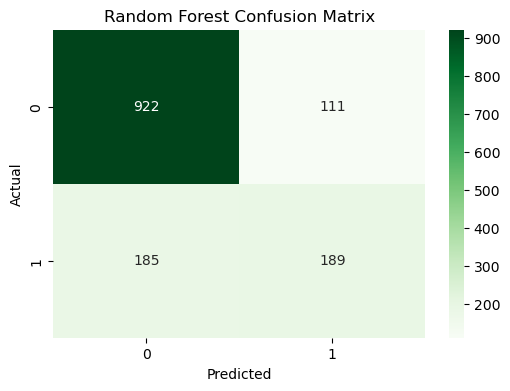

In [71]:
#confussion matrix
cm = confusion_matrix(y_test,log_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
#rf
cm_rf = confusion_matrix(y_test,rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


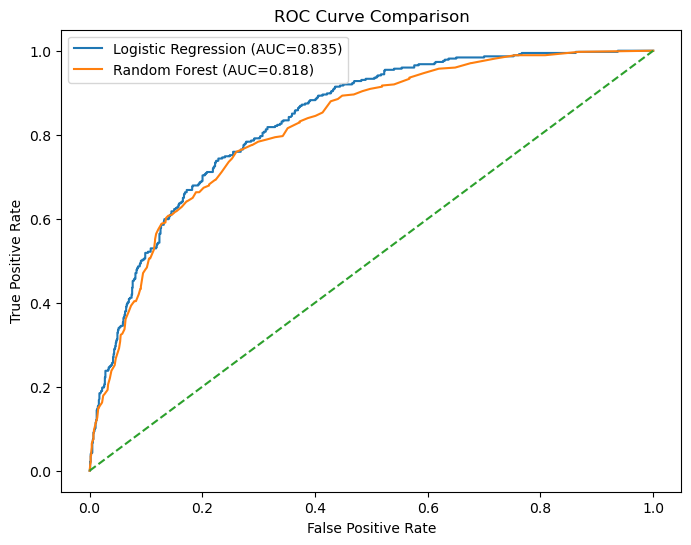

In [72]:
#ROC Curves
log_fpr, log_tpr, _ = roc_curve(y_test,log_model.predict_proba(X_test_scaled)[:,1])
rf_fpr, rf_tpr, _ = roc_curve(y_test,rf_model.predict_proba(X_test)[:,1])
plt.figure(figsize=(8,6))
plt.plot(log_fpr,log_tpr,label=f'Logistic Regression (AUC={log_auc:.3f})')
plt.plot(rf_fpr,rf_tpr,label=f'Random Forest (AUC={rf_auc:.3f})')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [73]:
print("Logistic Regression")
print(classification_report(y_test, log_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



# Model Evaluation Summary

Key findings:

- Logistic Regression achieved the strongest overall performance.
- Random Forest produced competitive results with slightly lower accuracy.
- Decision Tree showed weaker generalization and lower predictive performance.
- ROC-AUC scores indicate good discrimination between churned and non-churned customers.

Based on these results, Logistic Regression is selected as the final model due to its strong predictive performance and interpretability.

# Business Insights and Recommendations

The objective of this project was to predict customer churn using machine learning techniques and identify the factors influencing customer retention.

Three machine learning models were developed and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

The models were assessed using Accuracy, Precision, Recall, F1 Score, and ROC-AUC metrics.

# Model Performance Summary

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---------|---------|---------|---------|---------|---------|
| Logistic Regression | 79.53% | 63.87% | 52.94% | 57.89% | 83.47% |
| Decision Tree | 71.71% | 46.88% | 48.13% | 47.49% | 64.16% |
| Random Forest | 78.96% | 63.00% | 50.53% | 56.08% | 81.83% |

# Interpretation

Logistic Regression achieved the strongest overall performance and demonstrated the highest ROC-AUC score. The model effectively distinguishes between customers who are likely to churn and those who are likely to remain with the company.

Therefore, Logistic Regression was selected as the final model.

# Key Drivers of Customer Churn

Feature importance analysis identified several factors that strongly influence customer churn:

1. Total Charges
2. Customer Tenure
3. Revenue Per Month
4. Monthly Charges
5. Payment Method (Electronic Check)
6. Internet Service Type (Fiber Optic)
7. Contract Type

# Key Observations

- Customers with shorter tenure are more likely to churn.
- Customers on month-to-month contracts show higher churn rates.
- Customers paying via electronic check appear more likely to leave.
- Customers with higher monthly charges tend to churn more frequently.
- Long-term contracts improve customer retention.
- Customers with additional services such as Online Security and Tech Support are less likely to churn.

# Recommendations

Based on the findings, the company should consider the following strategies:

# 1. Strengthen Early Customer Engagement

Since new customers are more likely to churn, onboarding programs and proactive customer support should be prioritized during the first year.

# 2. Encourage Long-Term Contracts

Offering incentives for one-year and two-year contracts may improve customer retention.

# 3. Review Pricing Strategies

Customers with higher monthly charges show increased churn risk. The company should assess pricing structures and value propositions.

# 4. Promote Value-Added Services

Services such as Online Security and Tech Support appear to improve retention and should be actively marketed.

# 5. Investigate Electronic Check Customers

Customers using electronic check payment methods exhibit higher churn rates and may require targeted retention efforts.

# Conclusion

This project successfully developed machine learning models to predict customer churn in a telecommunications company.

The analysis identified customer tenure, pricing variables, contract type, and service subscriptions as major factors influencing churn behavior.

Among the evaluated models, Logistic Regression delivered the strongest performance with:

- Accuracy: 79.53%
- ROC-AUC: 83.47%

The model provides a practical tool for identifying at-risk customers and supporting data-driven retention strategies.

This project demonstrates the complete data science workflow, including:

- Data collection and exploration
- Data cleaning and preprocessing
- Feature engineering
- Model development
- Model evaluation
- Business insight generation

The resulting solution can help organizations reduce customer attrition and improve long-term profitability.

# Future Work

Potential improvements for this project include:

- Hyperparameter tuning using GridSearchCV
- Testing advanced models such as XGBoost and LightGBM
- Building a real-time churn prediction dashboard using Streamlit
- Deploying the model to the cloud for business use
- Incorporating additional customer behavioral data